In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df =pd.read_csv(r"C:\Users\User\Desktop\Credit_risk_analysis\data\processed\credit_risk_features.csv")

In [6]:
# overall default rate
default_rate = df["loan_status"].mean() * 100
print("Overall Default Rate:", round(default_rate,2),"%")

Overall Default Rate: 21.87 %


In [7]:
#default rate by loan default
grade_risk = (
    df.groupby("loan_grade")["loan_status"]
    .agg(["count", "mean"])
    .reset_index()
)

grade_risk["default_rate"] = grade_risk["mean"] * 100

print("\nDefault rate by loan grade:")
print(grade_risk)


Default rate by loan grade:
  loan_grade  count      mean  default_rate
0          A  10703  0.099598      9.959824
1          B  10384  0.163232     16.323190
2          C   6436  0.207582     20.758235
3          D   3620  0.590608     59.060773
4          E    963  0.644860     64.485981
5          F    241  0.705394     70.539419
6          G     64  0.984375     98.437500


In [8]:
#default rate by loan purpose
purpose_risk = (
    df.groupby("loan_intent")["loan_status"]
    .agg(["count", "mean"])
    .reset_index()
)

purpose_risk["default_rate"] = purpose_risk["mean"] * 100

print("\nDefault rate by purpose:")
print(purpose_risk)


Default rate by purpose:
         loan_intent  count      mean  default_rate
0  DEBTCONSOLIDATION   5189  0.286760     28.676045
1          EDUCATION   6409  0.172570     17.256982
2    HOMEIMPROVEMENT   3594  0.261547     26.154702
3            MEDICAL   6042  0.267627     26.762661
4           PERSONAL   5497  0.199018     19.901765
5            VENTURE   5680  0.148592     14.859155


In [9]:
#default rate by home ownership
home_risk = (
    df.groupby("person_home_ownership")["loan_status"]
    .mean()
    .mul(100)
)

print("\nDefault rate by home ownership:")
print(home_risk)


Default rate by home ownership:
person_home_ownership
MORTGAGE    12.620633
OTHER       31.132075
OWN          7.491221
RENT        31.615267
Name: loan_status, dtype: float64


In [10]:
#Default rate by previous default
previous_default_risk = (
    df.groupby("previous_default")["loan_status"]
    .mean()
    .mul(100)
)

print("\nDefault rate by previous default:")
print(previous_default_risk)


Default rate by previous default:
previous_default
0    18.436340
1    37.870855
Name: loan_status, dtype: float64


In [11]:
#default rate by dept burden
debt_risk = (
    df.groupby("high_debt_burden")["loan_status"]
    .mean()
    .mul(100)
)

print("\nDefault rate by debt burden:")
print(debt_risk)


Default rate by debt burden:
high_debt_burden
0    15.246589
1    65.573002
Name: loan_status, dtype: float64


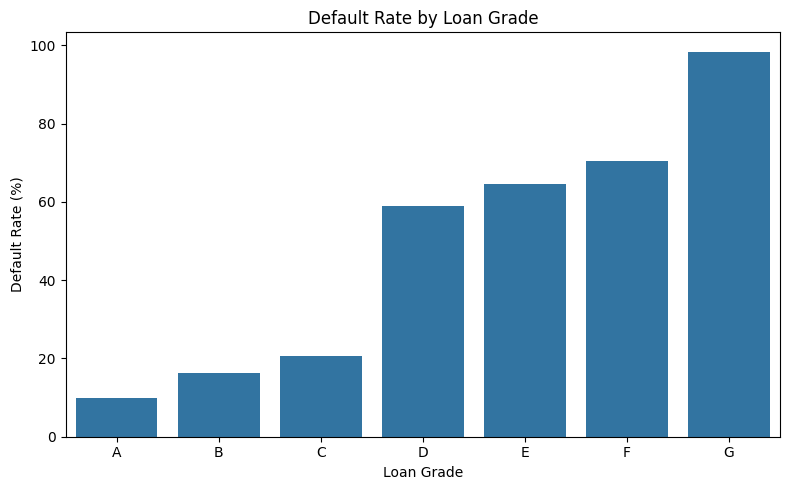

In [12]:
#visualization - Loan Grade

plt.figure(figsize=(8,5))

sns.barplot(data=grade_risk,x="loan_grade",y="default_rate")
plt.title("Default Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate (%)")
plt.tight_layout()

plt.savefig(r"../reports/default_rate_by_grade.png")
plt.show()

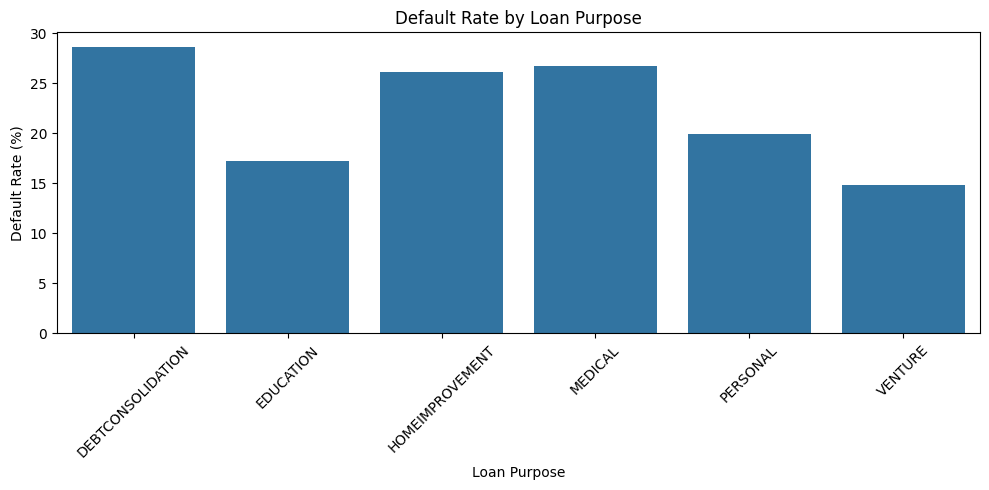

In [13]:
#Visualization - Loan Purpose

plt.figure(figsize=(10, 5))

sns.barplot(
    data=purpose_risk,
    x="loan_intent",
    y="default_rate"
)

plt.xticks(rotation=45)

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Default Rate (%)")

plt.tight_layout()

plt.savefig(
    "../reports/default_rate_by_purpose.png"
)

plt.show()

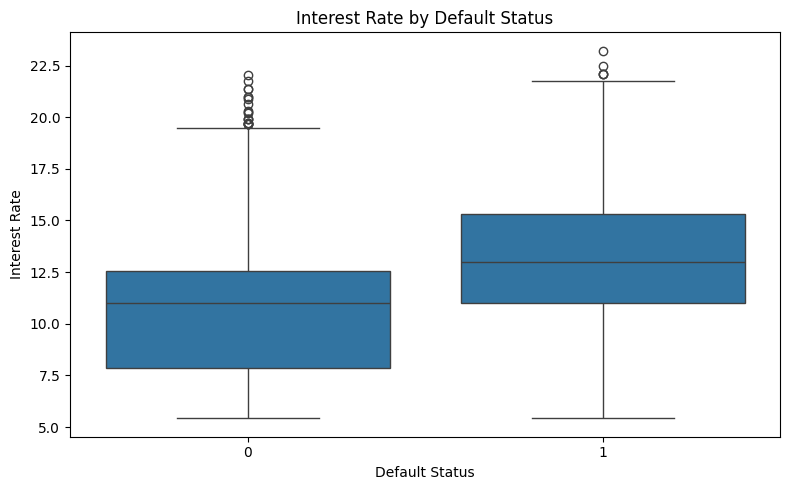

In [14]:
# Interest vs default

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="loan_int_rate"
)

plt.title("Interest Rate by Default Status")
plt.xlabel("Default Status")
plt.ylabel("Interest Rate")

plt.tight_layout()

plt.savefig(
    "../reports/interest_rate_default.png"
)

plt.show()